
## Robustness Decomposition + Bootstrap
Refactors `robustness_decomp_nadavVersion.ipynb` and adds the clustered bootstrap workflow from `decomp_bootstraping_nadavVersion.ipynb`. Run top-to-bottom to:
- fit the FE model and augment data,
- reproduce the robustness specs (score range, rewrite subsets, drop k=1, GPT baseline),
- compute essay-clustered bootstraps for each spec,
- write tables and a stacked-bar figure to `../../output/robustness_decomp/`.
Adjust `BOOT_REPS` for faster smoke tests.


In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from joblib import Parallel, delayed
from pyfixest.estimation import feols

sns.set_style("whitegrid")


In [2]:

BOOT_REPS = 500
RNG_SEED = 42

SAT_PATH = "../../data/results/sat_full/data_sat_scored.csv"
NEUTRAL_PATH = "../../data/results/no_desc/no_desc_scored.csv"

OUTPUT_DIR = "../../output/robustness_decomp/"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

for path in [OUTPUT_DIR, TABLE_DIR, FIG_DIR]:
    os.makedirs(path, exist_ok=True)

rng = np.random.default_rng(RNG_SEED)


### Helper functions

In [3]:

def mean_mask(s: pd.Series, mask: pd.Series) -> float:
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan


def fit_fe_and_augment(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.sort_values(["essay_id", "k"]).reset_index(drop=True).copy()
    res = feols("score_high_full ~ 1 | essay_id + k", data=df[df["k"] != 0])
    fes = res.fixef()
    df["fe_essay"] = df["essay_id"].map(fes["C(essay_id)"])
    df["fe_k"] = df["k"].map(fes["C(k)"])
    df["u"] = df["score_high_full"] - df["fe_essay"]
    df["diff"] = df["score_high_full"] - df["score_low_full"]
    return df


In [4]:

def compute_decomposition_point_estimates(df_in: pd.DataFrame):
    df_ = df_in.copy()

    # --- A) total gap (k==0)
    mA = (df_["low_SES"] == 0) & (df_["k"] == 0) & df_["score_high_full"].notna()
    mB = (df_["low_SES"] == 1) & (df_["k"] == 0) & df_["score_low_full"].notna()
    tmp_vals = pd.Series(np.nan, index=df_.index)
    tmp_vals[mA] = df_.loc[mA, "score_high_full"].astype(float)
    tmp_vals[mB] = df_.loc[mB, "score_low_full"].astype(float)

    group = pd.Series(np.nan, index=df_.index)
    group[mA] = 0
    group[mB] = 1
    m0 = group == 0
    m1 = group == 1

    mean0 = mean_mask(tmp_vals, m0)
    mean1 = mean_mask(tmp_vals, m1)
    total_gap = mean0 - mean1

    # --- B) content gap (k==0), use essay FE
    mK0 = df_["k"] == 0
    content_mean0 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"] == 0))
    content_mean1 = mean_mask(df_["fe_essay"], mK0 & (df_["low_SES"] == 1))
    content_gap = content_mean0 - content_mean1

    # --- C) style gap via residual u = score_high_full - fe_essay
    u_mean0 = mean_mask(df_["u"], mK0 & (df_["low_SES"] == 0))
    u_mean1 = mean_mask(df_["u"], mK0 & (df_["low_SES"] == 1))
    style_gap = u_mean0 - u_mean1

    # --- D) ranker-tilting (low-SES originals at k==0)
    m_tilt = (df_["low_SES"] == 1) & (df_["k"] == 0)
    others_gap = mean_mask(df_["score_high_full"] - df_["score_low_full"], m_tilt)

    return {
        "total_gap": total_gap,
        "content_gap": content_gap,
        "style_gap": style_gap,
        "others_gap": others_gap,
        "share_content": content_gap / total_gap if pd.notna(total_gap) and total_gap != 0 else np.nan,
        "share_style": style_gap / total_gap if pd.notna(total_gap) and total_gap != 0 else np.nan,
        "share_others": others_gap / total_gap if pd.notna(total_gap) and total_gap != 0 else np.nan,
    }


In [5]:

def bootstrap_decomposition(df_in: pd.DataFrame, B: int = BOOT_REPS, seed: int = RNG_SEED, desc: str = "Bootstrap reps"):
    df_base = df_in.sort_values(["essay_id", "k"]).reset_index(drop=True).copy()
    point_df = fit_fe_and_augment(df_base)

    essay_to_idx = df_base.groupby("essay_id").indices
    essay_ids = np.array(list(essay_to_idx.keys()))
    n_clusters = len(essay_ids)
    if n_clusters < 2:
        raise ValueError("Need at least two essays for clustered bootstrap.")

    rng_local = np.random.default_rng(seed)
    seeds = rng_local.integers(0, 2 ** 32 - 1, size=B, dtype=np.uint64)

    def one_rep(s: int) -> dict:
        rng_rep = np.random.default_rng(s)
        sampled = rng_rep.choice(essay_ids, size=n_clusters, replace=True)
        idx = np.concatenate([essay_to_idx[eid] for eid in sampled])
        df_b = df_base.iloc[idx].copy()
        df_b = fit_fe_and_augment(df_b)
        return compute_decomposition_point_estimates(df_b)

    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(one_rep)(int(s)) for s in tqdm(seeds, desc=desc)
    )

    boot_df_stats = pd.DataFrame(results)
    ci_bounds = {
        col: tuple(np.nanpercentile(boot_df_stats[col], [2.5, 97.5]))
        for col in boot_df_stats.columns
    }

    point_est = compute_decomposition_point_estimates(point_df)
    return boot_df_stats, ci_bounds, point_est, point_df


In [6]:

def run_scenario(label: str, df_source: pd.DataFrame, seed: int, save_prefix: str):
    boot_df, ci_bounds, point_est, point_df = bootstrap_decomposition(
        df_source,
        B=BOOT_REPS,
        seed=seed,
        desc=f"{label} bootstrap"
    )

    point_df.to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_rows.csv"), index=False)
    boot_df.to_csv(os.path.join(OUTPUT_DIR, f"{save_prefix}_bootstrap.csv"), index=False)

    stats_order = [
        "total_gap", "content_gap", "style_gap", "others_gap",
        "share_content", "share_style", "share_others",
    ]

    rows = []
    for stat in stats_order:
        lo, hi = ci_bounds[stat]
        rows.append({
            "scenario": label,
            "stat": stat,
            "point_estimate": point_est[stat],
            "ci_2.5": lo,
            "ci_97.5": hi,
        })

    shares = {
        "scenario": label,
        "content": point_est["share_content"],
        "style": point_est["share_style"],
        "others": point_est["share_others"],
    }

    return {
        "label": label,
        "point": point_est,
        "ci": ci_bounds,
        "rows": rows,
        "shares": shares,
        "boot_df": boot_df,
        "point_df": point_df,
    }


### Load data

In [7]:

df_sat_raw = pd.read_csv(SAT_PATH, encoding="ISO-8859-1", index_col=0)
df_sat_raw = df_sat_raw.sort_values(["essay_id", "k"]).reset_index(drop=True)

# GPT-neutral baseline
df_neutral_raw = pd.read_csv(NEUTRAL_PATH, encoding="ISO-8859-1", index_col=0)
df_neutral_raw = df_neutral_raw.sort_values(["essay_id", "k"]).reset_index(drop=True)

print(f"SAT rows: {len(df_sat_raw):,} | Neutral rows: {len(df_neutral_raw):,}")


SAT rows: 137,095 | Neutral rows: 145,173


### Scenario builders (same specs as the original robustness notebook)

In [8]:

def keep_score_two_to_five(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df[(df["true_score"] <= 5) & (df["true_score"] >= 2)]
    mask = (np.abs(df["k"] - df["true_score"]) <= 1) | (df["k"] == 0)
    return df[mask]


def keep_rewrites_1_2_5_6(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["k"].isin([0, 1, 2, 5, 6])].copy()


def drop_k1_rewrites(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["k"] != 1].copy()


### Run decompositions + bootstraps

In [9]:

scenario_results = {}
summary_rows = []
share_rows = []

sat_scenarios = [
    ("sat_baseline", "SAT (baseline)", lambda d: d.copy(), 42),
    ("sat_score25", "Score 2–5, |Δ| ≤ 1", keep_score_two_to_five, 43),
    ("sat_rewrites_1256", "Rewrites {1,2,5,6} only", keep_rewrites_1_2_5_6, 44),
    ("sat_drop_k1", "Drop k=1 rewrites", drop_k1_rewrites, 45),
]

for key, label, builder, seed in sat_scenarios:
    df_variant = builder(df_sat_raw)
    res = run_scenario(label, df_variant, seed=seed, save_prefix=key)
    scenario_results[key] = res
    summary_rows.extend(res["rows"])
    share_rows.append(res["shares"])

# Neutral baseline
neutral_res = run_scenario(
    "Baseline GPT", df_neutral_raw.copy(), seed=99, save_prefix="neutral_baseline"
)
scenario_results["neutral_baseline"] = neutral_res
summary_rows.extend(neutral_res["rows"])
share_rows.append(neutral_res["shares"])

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(TABLE_DIR, "robustness_bootstrap_summary_long.csv"), index=False)
summary_df


SAT (baseline) bootstrap: 100%|██████████| 500/500 [02:10<00:00,  3.84it/s]
Score 2–5, |Δ| ≤ 1 bootstrap: 100%|██████████| 500/500 [02:15<00:00,  3.70it/s]
Baseline GPT bootstrap: 100%|██████████| 500/500 [02:48<00:00,  2.97it/s]


,scenario,stat,point_estimate,ci_2.5,ci_97.5
0,SAT (baseline),total_gap,0.663307,0.634760,0.692610
1,SAT (baseline),content_gap,0.456066,0.432755,0.480606
2,SAT (baseline),style_gap,0.173050,0.163345,0.182920
3,SAT (baseline),others_gap,0.034191,0.029584,0.038742
4,SAT (baseline),share_content,0.687564,0.673702,0.699905
5,SAT (baseline),share_style,0.260890,0.248778,0.273987
6,SAT (baseline),share_others,0.051546,0.044179,0.058911
7,"Score 2–5, |Δ| ≤ 1",total_gap,0.546797,0.520277,0.573758
8,"Score 2–5, |Δ| ≤ 1",content_gap,0.385091,0.362355,0.407864
9,"Score 2–5, |Δ| ≤ 1",style_gap,0.129497,0.120784,0.138835


### Pivoted summary table (point ± CI)

In [10]:

def format_ci(row):
    return f"{row['point_estimate']:.3f} [{row['ci_2.5']:.3f}, {row['ci_97.5']:.3f}]"

summary_formatted = summary_df.copy()
summary_formatted["estimate_ci"] = summary_formatted.apply(format_ci, axis=1)
summary_pivot = summary_formatted.pivot(index="stat", columns="scenario", values="estimate_ci")

summary_pivot.to_csv(os.path.join(TABLE_DIR, "robustness_bootstrap_summary_pivot.csv"))
summary_pivot.to_latex(os.path.join(TABLE_DIR, "robustness_bootstrap_summary_pivot.tex"), escape=False)
summary_pivot


scenario,Baseline GPT,Drop k=1 rewrites,"Rewrites {1,2,5,6} only",SAT (baseline),"Score 2–5, |Δ| ≤ 1"
stat,,,,,
content_gap,"0.501 [0.474, 0.524]","0.472 [0.447, 0.498]","0.442 [0.420, 0.465]","0.456 [0.433, 0.481]","0.385 [0.362, 0.408]"
others_gap,"0.035 [0.030, 0.039]","0.034 [0.030, 0.039]","0.034 [0.030, 0.039]","0.034 [0.030, 0.039]","0.032 [0.028, 0.037]"
share_content,"0.762 [0.745, 0.776]","0.712 [0.696, 0.726]","0.666 [0.653, 0.681]","0.688 [0.674, 0.700]","0.704 [0.688, 0.719]"
share_others,"0.053 [0.046, 0.060]","0.052 [0.045, 0.059]","0.052 [0.044, 0.059]","0.052 [0.044, 0.059]","0.059 [0.050, 0.068]"
share_style,"0.186 [0.172, 0.201]","0.237 [0.224, 0.251]","0.282 [0.268, 0.296]","0.261 [0.249, 0.274]","0.237 [0.222, 0.251]"
style_gap,"0.122 [0.113, 0.132]","0.157 [0.148, 0.166]","0.187 [0.176, 0.198]","0.173 [0.163, 0.183]","0.129 [0.121, 0.139]"
total_gap,"0.657 [0.630, 0.682]","0.663 [0.636, 0.690]","0.663 [0.637, 0.690]","0.663 [0.635, 0.693]","0.547 [0.520, 0.574]"


### Stacked-bar figure for decomposition shares

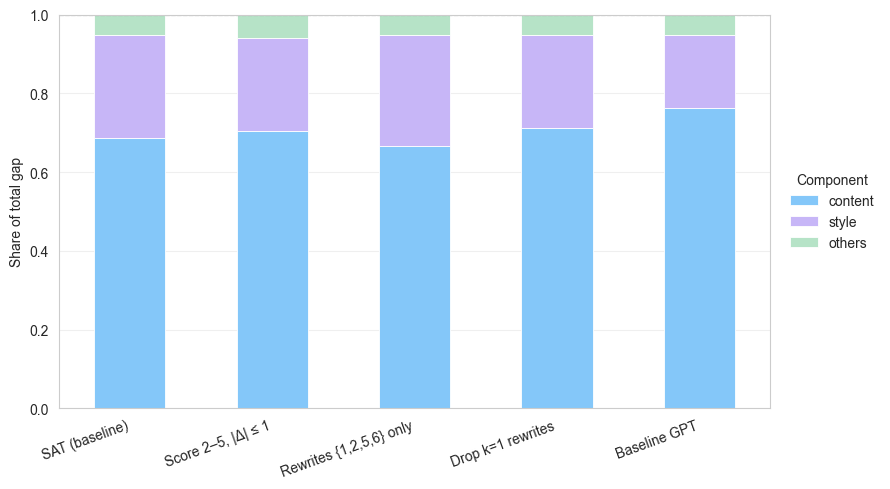

In [ ]:

COMP_ORDER = ["content", "style", "others"]
COMP_COLORS = {"content": "#84C7F9", "style": "#C7B6F7", "others": "#B6E3C7"}

shares_df = pd.DataFrame(share_rows).set_index("scenario")[COMP_ORDER]

ax = shares_df.plot(
    kind="bar",
    stacked=True,
    color=[COMP_COLORS[c] for c in COMP_ORDER],
    edgecolor="white",
    linewidth=0.6,
    figsize=(9, 5),
)

ax.set_ylabel("Share of total gap")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.axhline(1, color="gray", lw=0.8, linestyle="--")
plt.xticks(rotation=20, ha="right")
ax.legend(title="Component", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "robustness_decomposition_shares.pdf"), bbox_inches="tight")
plt.show()
